# 07 · Covariance and Correlation

So far we looked at one variable at a time. Now we look at **two variables together**: when one goes up, does the other go up, go down, or not care?

**What you will learn here**

1. Covariance: the direction of a relationship
2. Why covariance alone is not enough
3. Pearson correlation: strength of a **linear** relationship, from −1 to +1
4. Spearman rank correlation: for relationships that are monotonic but not straight
5. Traps: outliers, hidden groups (Simpson's paradox), and "correlation is not causation"

## The dataset: Palmer penguins

| | |
|---|---|
| **Name** | Palmer Penguins |
| **Source** | [seaborn-data on GitHub](https://github.com/mwaskom/seaborn-data/blob/master/penguins.csv), originally from Dr. Kristen Gorman and the Palmer Station LTER, Antarctica ([palmerpenguins](https://allisonhorst.github.io/palmerpenguins/)) |
| **Licence** | CC0 (public domain) |
| **Rows** | 344 penguins (333 after removing rows with missing values) |

A copy is saved in `data/penguins.csv`.

| Column | Meaning |
|---|---|
| `species` | Adelie, Chinstrap or Gentoo |
| `island` | Island in the Palmer Archipelago |
| `bill_length_mm` | Length of the bill (beak) in mm |
| `bill_depth_mm` | Depth (height) of the bill in mm |
| `flipper_length_mm` | Length of the flipper (wing) in mm |
| `body_mass_g` | Body mass in grams |
| `sex` | MALE / FEMALE |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"
SPECIES_COLOURS = {"Adelie": BLUE, "Chinstrap": ORANGE, "Gentoo": GREEN}

penguins = pd.read_csv("../data/penguins.csv").dropna()
print("Rows after dropping missing values:", len(penguins))
penguins.head()

Rows after dropping missing values: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


---
## 1. Covariance

> **Theory.** Covariance tells us the **direction** in which two variables move together.

| Pattern | Covariance | Example |
|---|---|---|
| X up → Y up | positive | Height and weight |
| X up → Y down | negative | Hours of gaming and exam marks |
| No pattern | close to 0 | Shoe size and IQ |

**Formula** (sample covariance)

$$\text{Cov}(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$

How it works: for each point, multiply "how far X is from its mean" by "how far Y is from its mean".

- Both above their mean → (+) × (+) = positive
- Both below → (−) × (−) = positive
- One above, one below → negative

If most points give positive products, X and Y move together.

> **Note:** Covariance of a variable with itself is its variance: $\text{Cov}(X, X) = \frac{\sum (x_i - \bar{x})^2}{n-1} = \text{Var}(X)$.

**Small example:** X = 2, 4, 6 and Y = 3, 5, 7

**Manual calculation.** $\bar{x} = 4$, $\bar{y} = 5$

| x | y | x − 4 | y − 5 | product |
|---|---|---|---|---|
| 2 | 3 | −2 | −2 | 4 |
| 4 | 5 | 0 | 0 | 0 |
| 6 | 7 | 2 | 2 | 4 |
| | | | **sum** | **8** |

Cov(X, Y) = 8 / (3 − 1) = **4**

In [2]:
x = np.array([2, 4, 6])
y = np.array([3, 5, 7])

products = (x - x.mean()) * (y - y.mean())
cov_by_hand = products.sum() / (len(x) - 1)

print("products:", products)
print("covariance by hand:", cov_by_hand)
# docs: https://numpy.org/doc/stable/reference/generated/numpy.cov.html
print("numpy np.cov:\n", np.cov(x, y))

products: [4. 0. 4.]
covariance by hand: 4.0
numpy np.cov:
 [[4. 4.]
 [4. 4.]]


`np.cov` returns a 2×2 **covariance matrix**: variances on the diagonal (Var(X) = 4, Var(Y) = 4), covariance off the diagonal (4).

### On real data: flipper length and body mass

In [3]:
flipper = penguins["flipper_length_mm"]
mass_g = penguins["body_mass_g"]

print("Cov(flipper mm, mass g) :", round(flipper.cov(mass_g), 1))
print("Cov(flipper mm, mass kg):", round(flipper.cov(mass_g / 1000), 2))

Cov(flipper mm, mass g) : 9852.2
Cov(flipper mm, mass kg): 9.85


Positive, so penguins with longer flippers tend to be heavier.

## 2. The problem with covariance

Look at the two numbers above. Same penguins, same relationship, but the covariance is **9852** in grams and **9.85** in kilograms. Covariance depends on the units, so:

- we can't say if 9852 is "strong" or "weak"
- we can't compare it with the covariance of two other variables

We need a version without units. That is correlation.

---
## 3. Pearson correlation coefficient

> **Theory.** Pearson's correlation **r** is the covariance divided by both standard deviations. This removes the units and squeezes the value into the range **−1 to +1**.

**Formula**

$$r = \frac{\text{Cov}(X, Y)}{s_X \, s_Y}$$

| r | Meaning |
|---|---|
| +1 | perfect straight line going up |
| around +0.7 | strong positive |
| around +0.3 | weak positive |
| 0 | no **linear** relationship |
| −1 | perfect straight line going down |

(These labels are rough guides, not strict rules.)

**Small example:** X = 2, 4, 6, Y = 3, 5, 7. Cov = 4, $s_X$ = 2, $s_Y$ = 2.

r = 4 / (2 × 2) = **1**. The three points are on a perfect straight line.

In [4]:
r_by_hand = np.cov(x, y)[0, 1] / (x.std(ddof=1) * y.std(ddof=1))
print("r by hand:", r_by_hand)
print("r numpy  :", np.corrcoef(x, y)[0, 1])

r by hand: 1.0
r numpy  : 1.0


### What different values of r look like

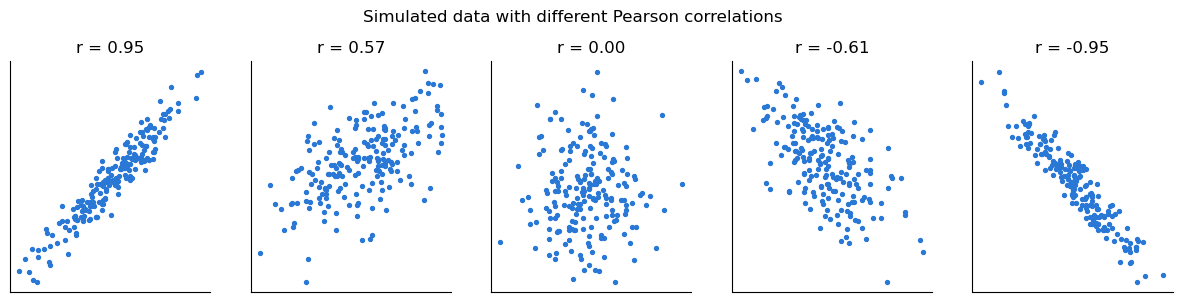

In [5]:
np.random.seed(0)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, target_r in zip(axes, [0.95, 0.6, 0.0, -0.6, -0.95]):
    data = np.random.multivariate_normal([0, 0], [[1, target_r], [target_r, 1]], size=200)
    r = np.corrcoef(data[:, 0], data[:, 1])[0, 1]
    ax.scatter(data[:, 0], data[:, 1], s=8, color=BLUE)
    ax.set_title(f"r = {r:.2f}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Simulated data with different Pearson correlations", y=1.05)
plt.show()

The closer r is to ±1, the more the points look like a line.

### On real data

In [6]:
r_flipper_mass = flipper.corr(mass_g)
print(f"Pearson r (flipper, mass in g) : {r_flipper_mass:.3f}")
print(f"Pearson r (flipper, mass in kg): {flipper.corr(mass_g / 1000):.3f}")

Pearson r (flipper, mass in g) : 0.873
Pearson r (flipper, mass in kg): 0.873


Same value in grams and kilograms. Units no longer matter.

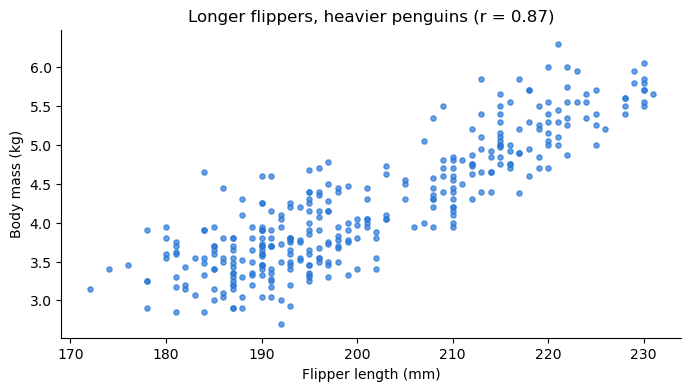

In [7]:
fig, ax = plt.subplots()
ax.scatter(flipper, mass_g / 1000, s=14, color=BLUE, alpha=0.7)
ax.set_title(f"Longer flippers, heavier penguins (r = {r_flipper_mass:.2f})")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (kg)")
plt.show()

A strong positive relationship (r = 0.87): the points form a clear upward band.

### Correlation matrix and heatmap

With several numeric columns, we compute all pairs at once.

In [8]:
numeric_columns = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
correlation_matrix = penguins[numeric_columns].corr()
correlation_matrix.round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.23,0.65,0.59
bill_depth_mm,-0.23,1.00,-0.58,-0.47
flipper_length_mm,0.65,-0.58,1.00,0.87
body_mass_g,0.59,-0.47,0.87,1.00


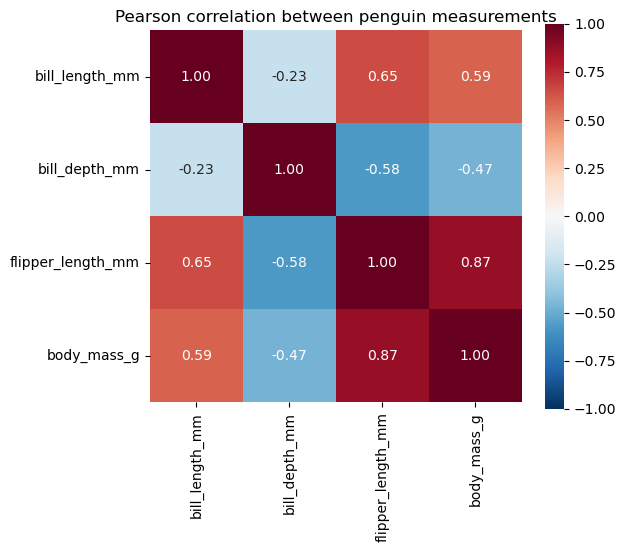

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
# docs: https://seaborn.pydata.org/generated/seaborn.heatmap.html
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Pearson correlation between penguin measurements")
plt.show()

Red = positive, blue = negative, white = near zero. Flipper length and body mass are the most related pair (0.87). Bill depth is negatively related to everything else, which is surprising: why would heavier penguins have **shallower** bills? We'll come back to this in section 5.

### Is the correlation significant?

`scipy.stats.pearsonr` also gives a p-value for H₀: "the true correlation is 0".

In [10]:
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
result = stats.pearsonr(flipper, mass_g)
print(f"r = {result.statistic:.3f}, p-value = {result.pvalue:.2e}")

r = 0.873, p-value = 3.13e-105


p is basically zero: with 333 penguins and r = 0.87, this relationship is certainly not luck.

---
## 4. Spearman rank correlation

> **Theory.** Pearson measures **straight-line** relationships. But some relationships always go up without being straight (for example y = x³). Spearman's correlation handles this by first replacing each value by its **rank** (1st, 2nd, 3rd...) and then computing Pearson on the ranks.

It measures **monotonic** relationships: "when X goes up, does Y always go up (or always go down)?", no matter the shape.

**Formula**

$$r_s = \text{Pearson}(\text{rank}(X), \text{rank}(Y))$$

When there are no ties, this simplifies to:

$$r_s = 1 - \frac{6 \sum d_i^2}{n (n^2 - 1)}$$

where $d_i$ is the difference between the two ranks of point i.

**Small example:** X = 1, 3, 7, 0, 8 and Y = 2, 4, 5, 7, 1

**Manual calculation** (rank 1 = smallest)

| X | Y | rank X | rank Y | d | d² |
|---|---|---|---|---|---|
| 1 | 2 | 2 | 2 | 0 | 0 |
| 3 | 4 | 3 | 3 | 0 | 0 |
| 7 | 5 | 4 | 4 | 0 | 0 |
| 0 | 7 | 1 | 5 | −4 | 16 |
| 8 | 1 | 5 | 1 | 4 | 16 |
| | | | | **sum** | **32** |

$r_s = 1 - \dfrac{6 \times 32}{5 \times (25 - 1)} = 1 - \dfrac{192}{120} = 1 - 1.6 = -0.6$

In [11]:
X = pd.Series([1, 3, 7, 0, 8])
Y = pd.Series([2, 4, 5, 7, 1])

rank_x = X.rank()
rank_y = Y.rank()
d = rank_x - rank_y

n = len(X)
rs_by_hand = 1 - 6 * (d ** 2).sum() / (n * (n ** 2 - 1))

print("ranks of X:", rank_x.tolist())
print("ranks of Y:", rank_y.tolist())
print("Spearman by hand  :", round(rs_by_hand, 3))
print("Pearson on ranks  :", round(rank_x.corr(rank_y), 3))
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
print("scipy spearmanr   :", round(stats.spearmanr(X, Y).statistic, 3))

ranks of X: [2.0, 3.0, 4.0, 1.0, 5.0]
ranks of Y: [2.0, 3.0, 4.0, 5.0, 1.0]
Spearman by hand  : -0.6
Pearson on ranks  : -0.6
scipy spearmanr   : -0.6


> **Check:** All three agree: −0.6.

### Pearson vs Spearman on a curve

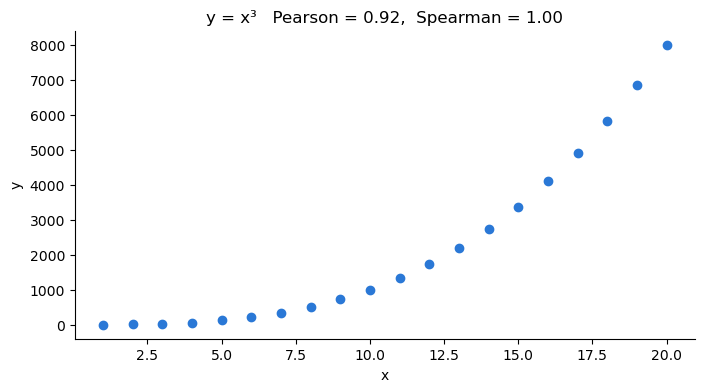

In [12]:
x_curve = np.arange(1, 21)
y_curve = x_curve ** 3

pearson_curve = np.corrcoef(x_curve, y_curve)[0, 1]
spearman_curve = stats.spearmanr(x_curve, y_curve).statistic

fig, ax = plt.subplots()
ax.scatter(x_curve, y_curve, color=BLUE)
ax.set_title(f"y = x³   Pearson = {pearson_curve:.2f},  Spearman = {spearman_curve:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

Y **always** goes up when X goes up, so Spearman gives a perfect 1.00. Pearson gives less than 1 because the points don't lie on a straight line.

### Spearman is also robust to outliers

Let's take the flipper/mass data and add a single wrong row, like a typo that turned 4.2 kg into 42 kg.

In [13]:
flipper_bad = pd.concat([flipper, pd.Series([175])], ignore_index=True)
mass_bad = pd.concat([mass_g, pd.Series([42000])], ignore_index=True)

print("                 Pearson  Spearman")
print(f"clean data     :  {flipper.corr(mass_g):.3f}    {flipper.corr(mass_g, method='spearman'):.3f}")
print(f"with 1 typo    :  {flipper_bad.corr(mass_bad):.3f}    {flipper_bad.corr(mass_bad, method='spearman'):.3f}")

                 Pearson  Spearman
clean data     :  0.873    0.840
with 1 typo    :  0.221    0.824


One bad row out of 334 dropped Pearson a lot, while Spearman barely moved. Ranks don't care how far away an extreme value is, only its position. When you're not sure about outliers, compute both. If they disagree a lot, look at the data.

---
## 5. Traps

### Trap 1: hidden groups (Simpson's paradox)

Earlier we saw a **negative** correlation between bill length and bill depth. Let's plot it, coloured by species.

In [14]:
overall_r = penguins["bill_length_mm"].corr(penguins["bill_depth_mm"])
print(f"All penguins together: r = {overall_r:.2f}")
for species, group in penguins.groupby("species"):
    r = group["bill_length_mm"].corr(group["bill_depth_mm"])
    print(f"{species:10s}: r = {r:.2f}")

All penguins together: r = -0.23
Adelie    : r = 0.39
Chinstrap : r = 0.65
Gentoo    : r = 0.65


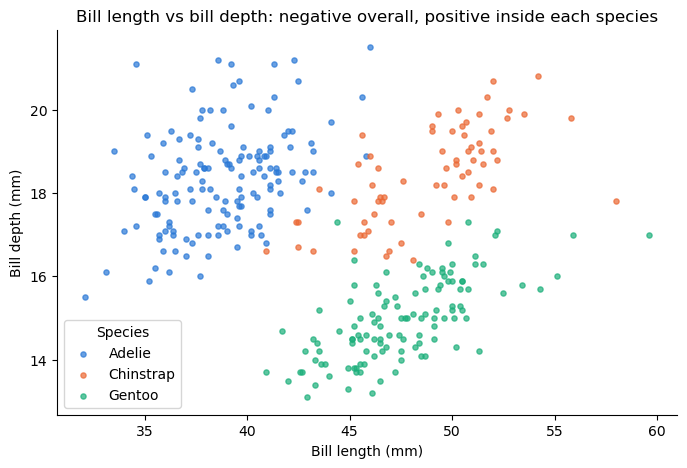

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
for species, group in penguins.groupby("species"):
    ax.scatter(group["bill_length_mm"], group["bill_depth_mm"], s=14, alpha=0.7,
               color=SPECIES_COLOURS[species], label=species)
ax.set_title("Bill length vs bill depth: negative overall, positive inside each species")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.legend(title="Species")
plt.show()

Inside **each** species, longer bills are also deeper (positive r). But Gentoo penguins have long and shallow bills, and Adelie have short and deep bills. When we mix the species, the groups create an overall **negative** trend that is true for no single species.

This is called **Simpson's paradox**. Lesson: before trusting a correlation, check whether hidden groups are mixing together.

Read more: [Simpson's paradox (Wikipedia)](https://en.wikipedia.org/wiki/Simpson%27s_paradox)

### Trap 2: correlation is not causation

Ice cream sales and drowning accidents are positively correlated. Ice cream doesn't cause drowning: hot weather drives both. A third variable that drives both is called a **confounder**.

Flipper length and body mass are correlated because both grow with the overall size of the penguin. Stretching a penguin's flippers would not make it heavier. To claim causation we need a controlled experiment, and that's what A/B testing is for (see the experimentation folder).

### Trap 3: r = 0 doesn't mean "no relationship"

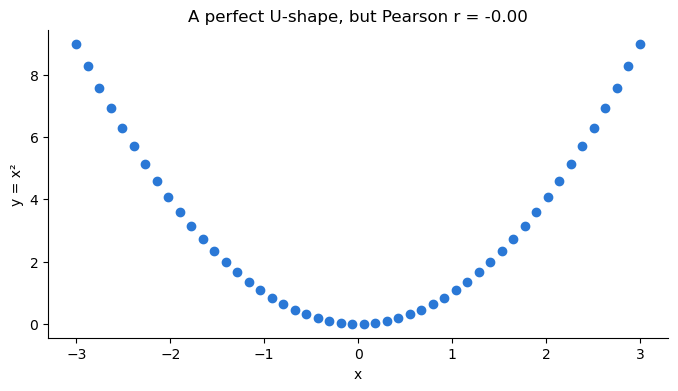

In [16]:
x_u = np.linspace(-3, 3, 50)
y_u = x_u ** 2

fig, ax = plt.subplots()
ax.scatter(x_u, y_u, color=BLUE)
ax.set_title(f"A perfect U-shape, but Pearson r = {np.corrcoef(x_u, y_u)[0, 1]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("y = x²")
plt.show()

Y depends **completely** on X, but r = 0 because the relationship is not a line (and not monotonic, so Spearman is 0 too). **Always plot your data**, never trust a single number.

---
## Summary

| Measure | Range | Captures | Weak point |
|---|---|---|---|
| Covariance | −∞ to +∞ | Direction | Depends on units, can't judge strength |
| Pearson r | −1 to +1 | Linear relationships | Sensitive to outliers, misses curves |
| Spearman r_s | −1 to +1 | Monotonic relationships (always up or always down) | Misses U-shapes too |

Three rules of thumb:

1. Plot first, compute second.
2. Check for hidden groups.
3. Correlation shows association, not cause.

## What's next

In **08 · Other Distributions and the Central Limit Theorem** we meet the Bernoulli, binomial, Poisson, log-normal and Pareto distributions, learn to check normality with a Q-Q plot, and see why sample means are normal even when the data is not.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapter 8 (introduction to linear regression, correlation)
- [Pearson correlation coefficient, Wikipedia](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) · [Spearman's rank correlation, Wikipedia](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)
- [Correlation does not imply causation, Wikipedia](https://en.wikipedia.org/wiki/Correlation_does_not_imply_causation) · [Anscombe's quartet, Wikipedia](https://en.wikipedia.org/wiki/Anscombe%27s_quartet)
- Horst, Hill & Gorman (2020), [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) (where the dataset comes from)